# Task 2 - Exploratory Data Analysis & Business Intelligence

## Importing Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading Cleaned Dataset

In [13]:
orders = pd.read_csv("../cleaned_data/orders_cleaned.csv")

In [14]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,purchase_year,purchase_month,purchase_day,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017,10,2,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,2018,7,24,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018,8,8,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017,11,18,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2018,2,13,False


## Order Status Distribution

In [15]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Order Status Visualization

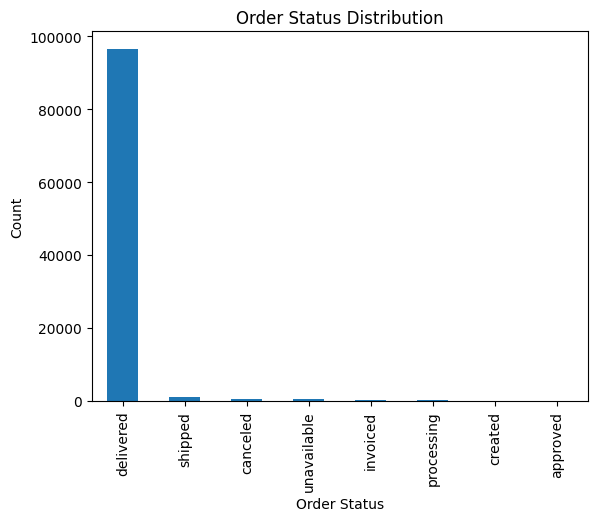

In [16]:
orders['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

## Monthly Order Trend

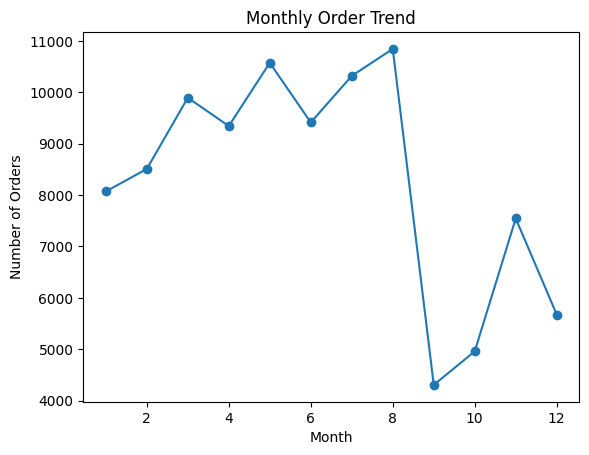

In [17]:
monthly_orders = orders['purchase_month'].value_counts().sort_index()

monthly_orders.plot(kind='line', marker='o')

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

## Delivery Time Distribution

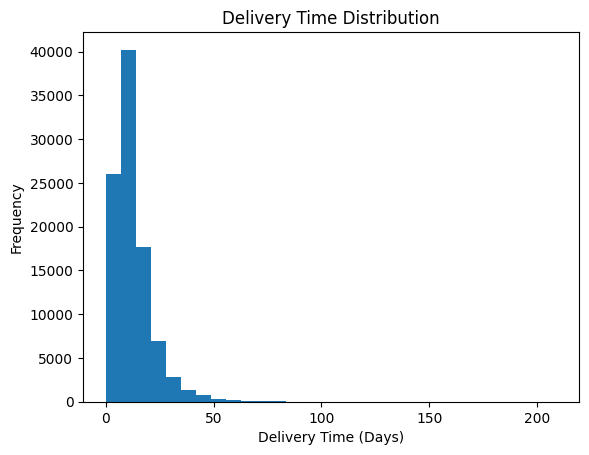

In [18]:
orders['delivery_time_days'].plot(kind='hist', bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

plt.show()

## Late Delivery Analysis

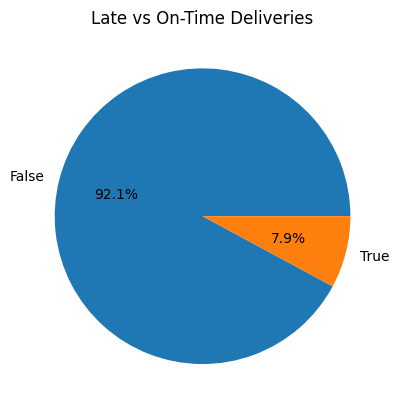

In [19]:
orders['is_late_delivery'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Late vs On-Time Deliveries")
plt.ylabel("")

plt.show()

## Business Question 1 - Which Month Had the Highest Orders?

In [20]:
monthly_orders = orders['purchase_month'].value_counts().sort_index()

print(monthly_orders)

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: count, dtype: int64


## Average Delivery Time by Month

In [21]:
avg_delivery = orders.groupby('purchase_month')['delivery_time_days'].mean()

print(avg_delivery)

purchase_month
1     13.489065
2     15.724449
3     14.941774
4     11.884628
5     10.890713
6      9.702199
7      9.518249
8      8.644158
9     11.410985
10    11.854465
11    14.699506
12    14.934712
Name: delivery_time_days, dtype: float64


## Visualization of Average Delivery Time by Month

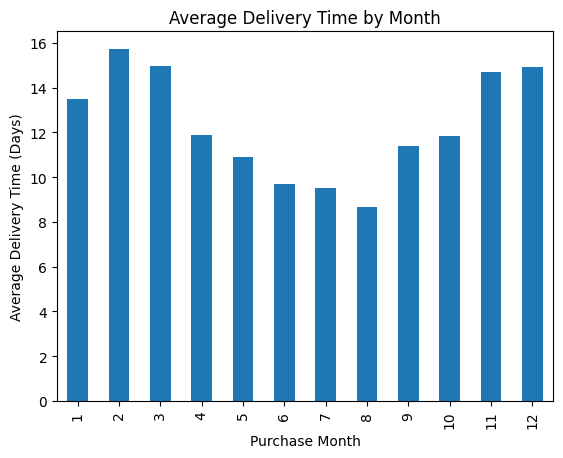

In [22]:
avg_delivery.plot(kind='bar')

plt.title("Average Delivery Time by Month")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

## Correlation Analysis

In [23]:
numeric_data = orders[['delivery_time_days', 'purchase_month']]

In [24]:
numeric_data.corr()

,delivery_time_days,purchase_month
delivery_time_days,1.000000,-0.054398
purchase_month,-0.054398,1.000000


## Heatmap Visualization

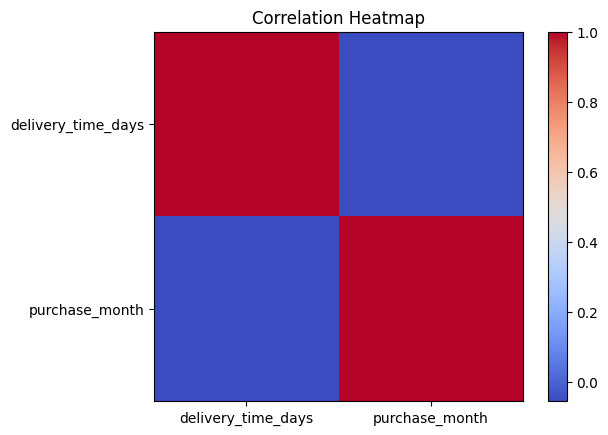

In [25]:
import matplotlib.pyplot as plt

plt.imshow(numeric_data.corr(), cmap='coolwarm')

plt.colorbar()

plt.xticks([0,1], numeric_data.columns)
plt.yticks([0,1], numeric_data.columns)

plt.title("Correlation Heatmap")

plt.show()

## SQL-Style Business Questions

### Business Question 1: How many orders were placed each month?

In [26]:
orders.groupby('purchase_month').size()

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
dtype: int64

### Business Question 2: Which Months Had the Highest Late Deliveries?

In [27]:
late_deliveries = orders.groupby('purchase_month')['is_late_delivery'].sum()

print(late_deliveries)

purchase_month
1      487
2     1102
3     1638
4      542
5      684
6      204
7      409
8      799
9      217
10     240
11    1043
12     462
Name: is_late_delivery, dtype: int64


## Visualization of Late Deliveries by Month

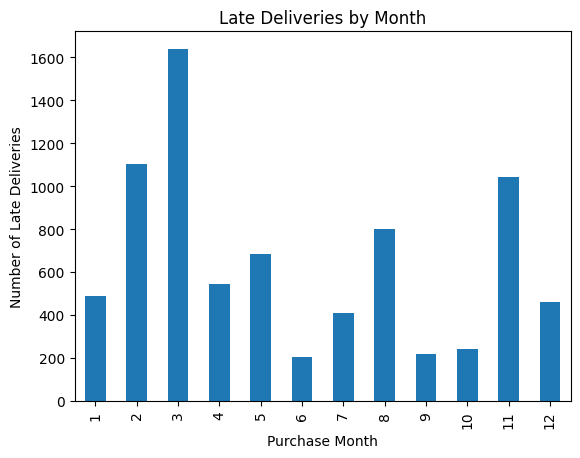

In [28]:
late_deliveries.plot(kind='bar')

plt.title("Late Deliveries by Month")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Late Deliveries")

plt.show()


### Business Question 3: What is the Average Delivery Time Per Month?

In [29]:
avg_delivery = orders.groupby('purchase_month')['delivery_time_days'].mean()

print(avg_delivery)

purchase_month
1     13.489065
2     15.724449
3     14.941774
4     11.884628
5     10.890713
6      9.702199
7      9.518249
8      8.644158
9     11.410985
10    11.854465
11    14.699506
12    14.934712
Name: delivery_time_days, dtype: float64


## Visualization of Average Delivery Time

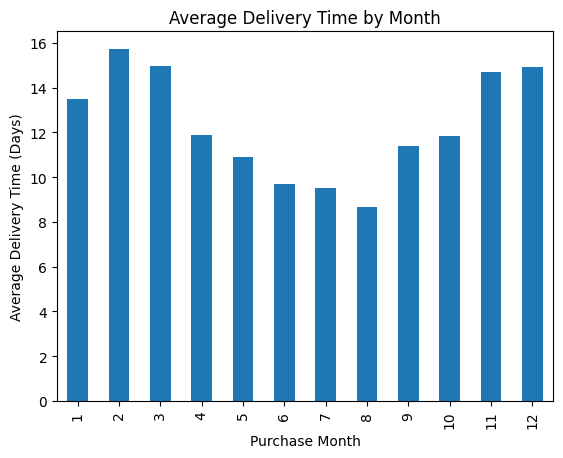

In [30]:
avg_delivery.plot(kind='bar')

plt.title("Average Delivery Time by Month")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

## Correlation Analysis

In [32]:
numeric_data = orders[['delivery_time_days', 'purchase_month']]

In [34]:
numeric_data.corr()

,delivery_time_days,purchase_month
delivery_time_days,1.000000,-0.054398
purchase_month,-0.054398,1.000000


## Correlation Heatmap

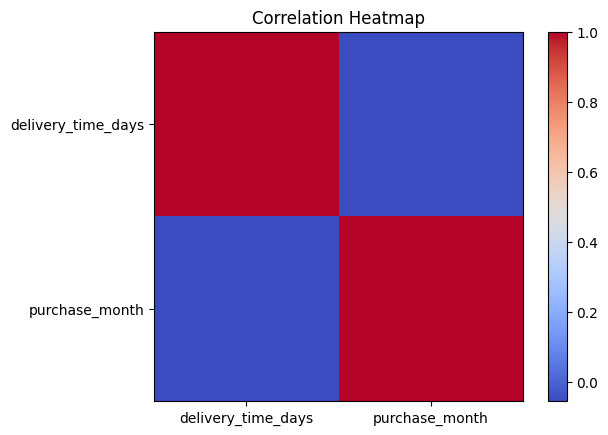

In [36]:
plt.imshow(numeric_data.corr(), cmap='coolwarm')

plt.colorbar()

plt.xticks([0,1], numeric_data.columns)
plt.yticks([0,1], numeric_data.columns)

plt.title("Correlation Heatmap")

plt.show()

## Key Business Insights

### Insights
- Most orders were successfully delivered.
- Late deliveries were relatively low compared to total deliveries.
- Certain months experienced higher delivery delays.
- Average delivery time was approximately 12 days.
- Delivery performance varied across months.

## Conclusion

This exploratory data analysis helped identify delivery patterns, operational efficiency, and customer order trends within the e-commerce dataset. The analysis provides useful business insights for logistics optimization and performance monitoring.

In [37]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,purchase_year,purchase_month,purchase_day,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017,10,2,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,2018,7,24,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018,8,8,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017,11,18,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2018,2,13,False
